In [1]:
import math
from pathlib import Path
import cvxpy as cp
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.dataset import *
from mis_dro.likelihood import sample_likelihood
from mis_dro.bayes_conjugates import *

In [2]:
replication = 0
dataset = "newsvendor"
dgp = "normal"
likelihood = "normal"
posterior = "normal_gamma"
num_observations = 20
num_test_observations = 200
num_likelihood_samples = 50
num_posterior_samples = 50
dim = 1
contamination = 0.0
generator = np.random.default_rng(seed=replication)

In [3]:
data = sample_dgp(
    dgp, num_observations, dim=dim, contamination=contamination, generator=generator
)
data_eval = sample_dgp(
    dgp, num_test_observations, dim=dim, contamination=0.0, generator=generator
)

In [4]:
theta_prior = default_prior_params(posterior, dim=dim)
theta_posterior = get_posterior_params(posterior, data, theta_prior)
bas_sample = derive_analytical_posterior_params(
    posterior, theta_posterior
)
bdro_sample = normal_gamma_rvs(num_posterior_samples, *theta_posterior, generator=generator)


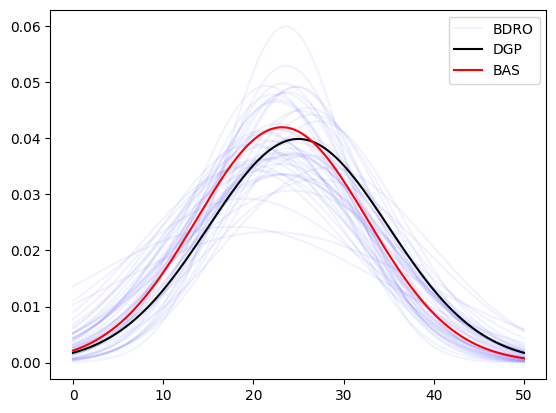

In [6]:
x = np.linspace(0,50,1000)
dgp_mean = 25.0
dgp_std = 10.0
for i in range(num_posterior_samples):
    if i == 0:
        label="BDRO"
    else:
        label="_nolegend_"
    plt.plot(x, sp.stats.norm.pdf(x, loc=bdro_sample[i,0],scale=bdro_sample[i,1]), label=label, color="blue", alpha=0.05)
plt.plot(x, sp.stats.norm.pdf(x, loc=dgp_mean, scale=dgp_std), label="DGP", color="black")
plt.plot(x, sp.stats.norm.pdf(x, loc=bas_sample[0,0],scale=bas_sample[0,1]), label="BAS", color="red")
plt.legend()